In [1]:
import torch

def convert_tensor_types(input_tensor):
# 定义所有需要转换的张量类型及其后缀形式
    dtype_conversions = {
    '32位浮点数':(torch.float32,'FloatTensor'),
    '64位浮点数':(torch.float64,'DoubleTensor'),
    '16位浮点数':(torch.float16,'HalfTensor'),
    '8位无符号整数':(torch.uint8,'ByteTensor'),
    '8位有符号整数':(torch.int8,'CharTensor'),
    '16位有符号整数':(torch.int16,'ShortTensor'),
    '32位有符号整数':(torch.int32,'IntTensor'),
    '64位有符号整数':(torch.int64,'LongTensor'),
    '布尔值':(torch.bool,'BoolTensor')

    }

    print(f"原始张量:{input_tensor}")
    print(f"原始数据类型:{input_tensor.dtype}\n")

    for name, (dtype, suffix) in dtype_conversions.items ():
        converted_tensor = input_tensor.to(dtype)
        print(f"转换为{name}({suffix}):")
        print(converted_tensor)
        print(f"转换后的数据类型:{converted_tensor.dtype}\n")

In [2]:
import torch
x = torch.arange(6)
x

tensor([0, 1, 2, 3, 4, 5])

In [3]:
x.shape

torch.Size([6])

In [4]:
x.numel() #处理：返回张量中的元素数量

6

In [5]:
#创建一维张量
x1 = torch.tensor([1, 2, 3, 4, 5])
#numel()返回张量中的元素数量
elem_count = x1.numel()
print(f'一维张量: {x1}, 元素数量: {elem_count}')


一维张量: tensor([1, 2, 3, 4, 5]), 元素数量: 5


In [6]:
x2 = torch.randn(2, 3, 4) #创建一个2x3x4的三维张量,2, 3, 4分别为深度、高度、宽度
elem_count_2 = x2.numel()
print(f'三维张量: {x2}, 元素数量: {elem_count_2}')

三维张量: tensor([[[ 0.1519, -0.4747, -1.5474, -0.3074],
         [ 0.0598, -0.6689, -1.8582,  1.0596],
         [ 0.4462, -1.1722,  1.6159,  1.7737]],

        [[-0.6441, -1.5237,  1.2146,  0.0550],
         [-0.5718, -4.3738,  0.5736, -1.0334],
         [ 0.4607, -2.5816, -1.2643,  1.2141]]]), 元素数量: 24


In [7]:
#空张量的numel
x3 = torch.tensor([])
elem_count_3 = x3.numel()
print(f'空张量: {x3}, 元素数量: {elem_count_3}')

空张量: tensor([]), 元素数量: 0


In [8]:
X = x.reshape(3, 2)
X

tensor([[0, 1],
        [2, 3],
        [4, 5]])

## Sigmoid 函数详解
### 什么是 Sigmoid 函数？

从数学定义上讲，Sigmoid函数将任意实数输入映射到 $(0, 1)$ 的区间内。公式：$$\sigma(x) = \frac{1}{1 + e^{-x}}$$
- 主要特性：输出范围： $(0, 1)$。无论输入 $x$ 多大或多小，输出永远在0到1之间。
- 单调性： 单调递增。
- 平滑性： 处处可导（这对反向传播算法非常重要）。

### 2. 在深度学习中的核心用途

Sigmoid 在深度学习中主要有两个关键用途：

#### A. 作为输出层的激活函数（二分类问题）

这是 Sigmoid 目前最主要的应用场景。

- **概率解释：** 因为 Sigmoid 的输出在 0 到 1 之间，它非常适合用来表示**概率**。
- **场景：** 假设你在做一个“猫狗识别”模型（二分类）。你希望模型输出“这是一只猫的概率”。
  - 如果模型输出 $0.95$，代表有 95% 的概率是猫。
  - 如果模型输出 $0.05$，代表只有 5% 的概率是猫。
- **配合损失函数：** 通常与**二元交叉熵损失函数 (Binary Cross-Entropy Loss)** 配合使用。

#### B. 门控机制（Gating Mechanisms）

在循环神经网络（RNN）的变体，如 **LSTM（长短期记忆网络）** 和 **GRU** 中，Sigmoid 起到了“开关”的作用。

- **控制信息流：** 神经网络需要决定哪些信息该“记住”，哪些该“遗忘”。
- **原理：**
  - Sigmoid 输出 $\approx 0$：代表**关闭**（阻断信息通过）。
  - Sigmoid 输出 $\approx 1$：代表**开启**（允许信息通过）。
- **例子：** LSTM 中的“遗忘门”（Forget Gate）就是通过 Sigmoid 来计算保留多少上一时刻的记忆。

开始训练线性回归模型...
初始参数：b0 = 0.0130, b1 = 1.4535
Epoch [100/1000], Loss: 0.2516, b0: 0.1904, b1: 0.5411
Epoch [200/1000], Loss: 0.2181, b0: 0.3684, b1: 0.5138
Epoch [300/1000], Loss: 0.2070, b0: 0.4704, b1: 0.4981
Epoch [400/1000], Loss: 0.2034, b0: 0.5289, b1: 0.4891
Epoch [500/1000], Loss: 0.2022, b0: 0.5625, b1: 0.4839
Epoch [600/1000], Loss: 0.2018, b0: 0.5817, b1: 0.4810
Epoch [700/1000], Loss: 0.2017, b0: 0.5927, b1: 0.4793
Epoch [800/1000], Loss: 0.2017, b0: 0.5991, b1: 0.4783
Epoch [900/1000], Loss: 0.2017, b0: 0.6027, b1: 0.4778
Epoch [1000/1000], Loss: 0.2016, b0: 0.6048, b1: 0.4774
训练完成！
最终参数：b0 = 0.6048, b1 = 0.4774
拟合方程：y = 0.6048 + 0.4774 * x
可视化图像已保存到输出目录。


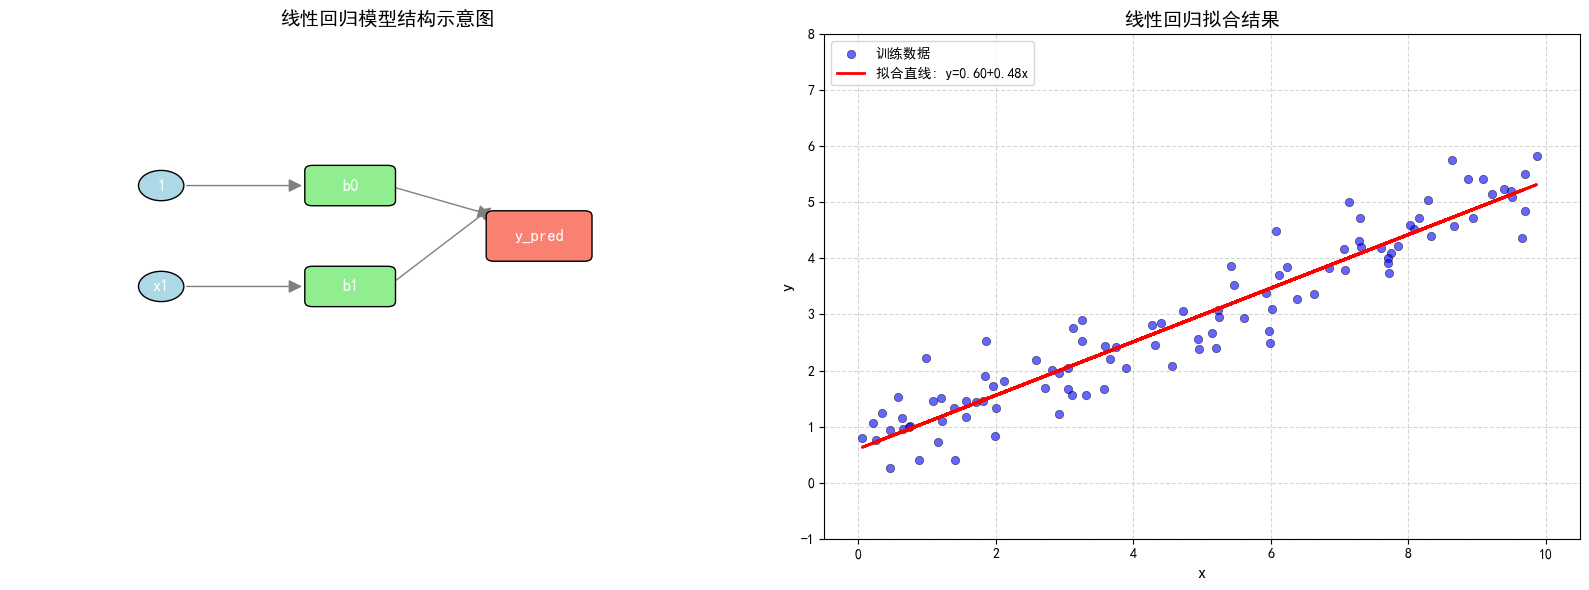

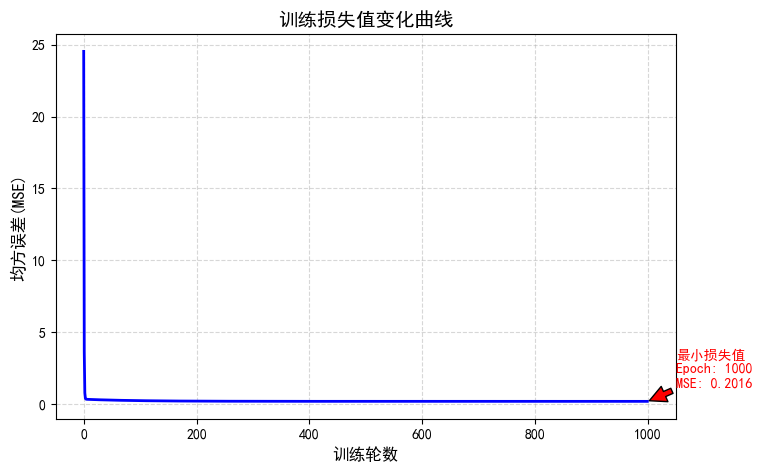


所有文件已保存到目录: d:\python_demo\coding\deepLearning\output


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch 
import warnings

# ================配置部分==================
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
# plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题
# plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题
warnings.filterwarnings("ignore")  # 忽略警告信息
np.random.seed(42)  # 设置随机种子，确保结果可复现

n_samples = 100  # 样本数量
x = np.random.uniform(0, 10, n_samples)  # 在0到10之间均匀分布生成100个样本点
noise = np.random.normal(0, 0.5, n_samples)  # 生成噪声

# 生成目标变量y，真实关系为y = 0.5 + 0.5 * x + 噪声
y = 0.5 + 0.5 * x + noise

# =============数据预处理=============
X_train = x.reshape(-1, 1)  # 将输入特征x转换为二维数组
y_train = y.reshape(-1, 1)  # 将目标变量y转换为二维数组

# =============神经网络参数初始化=============
b0 = np.random.randn()  # 偏置项（截距）
b1 = np.random.randn()  # 权重项（斜率）

# ========定义神经网络函数========
def forward(x, b0, b1):
    """计算线性模型的预测值"""
    return b0 + b1 * x

def compute_loss(y_pred, y_true):
    """计算均方误差 (MSE)"""
    # 修复：原代码使用了 torch.mean，这里是 numpy 环境，应使用 np.mean
    return np.mean((y_pred - y_true) ** 2)

# =========训练超参数设置=========
learning_rate = 0.01
num_epochs = 1000
loss_history = []

# ==================开始训练====================
print("=" * 50)
print("开始训练线性回归模型...")
print("=" * 50)
print(f"初始参数：b0 = {b0:.4f}, b1 = {b1:.4f}")
print("=" * 50)

for epoch in range(num_epochs):
    # 1. 前向传播
    y_pred = forward(X_train, b0, b1)
    
    # 2. 计算损失值
    loss = compute_loss(y_pred, y_train)
    loss_history.append(loss)
    
    # 修复：移除 loss.backward()，因为这是 PyTorch 的方法，Numpy 需要手动计算梯度
    
    # 3. 反向传播计算梯度
    error = y_pred - y_train
    
    # 计算损失函数对 b0 的偏导数
    grad_b0 = 2 * np.mean(error)
    
    # 计算损失函数对 b1 的偏导数
    grad_b1 = 2 * np.mean(error * X_train)
    
    # 4. 参数更新：梯度下降
    b0 -= learning_rate * grad_b0
    b1 -= learning_rate * grad_b1
    
    # =============打印训练过程中的信息=============
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss:.4f}, b0: {b0:.4f}, b1: {b1:.4f}")

# ============训练结束===========
print("=" * 50)
print("训练完成！")
print(f"最终参数：b0 = {b0:.4f}, b1 = {b1:.4f}")
print(f"拟合方程：y = {b0:.4f} + {b1:.4f} * x")
print("=" * 50)

# ===========模型预测==========
predicted = forward(X_train, b0, b1)

# ==========创建输出目录===========
output_dir = "output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# =========== 创建可视化 ========
fig = plt.figure(figsize=(16, 6))

# 子图1：线性回归模型结构示意图
ax1 = plt.subplot(1, 2, 1)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')  # 关闭坐标轴显示

# ============控制输入层节点===========
input_y_pos = [7, 5]
input_labels = ['1', 'x1']
input_nodes = []

for i, (y_pos, label) in enumerate(zip(input_y_pos, input_labels)):
    # 创建圆形补丁
    circle = plt.Circle((2, y_pos), 0.3, color='lightblue', ec='black', zorder=2)
    # 修复：原代码这里写的是 ax2.add_patch，此时 ax2 未定义，应为 ax1
    ax1.add_patch(circle)
    ax1.text(2, y_pos, label, fontsize=12, ha='center', va='center', zorder=4, color='white')
    # 修复：append 只能接受一个参数，需要加括号变成元组
    input_nodes.append((2, y_pos))

# ===========绘制参数节点===========
param_pos = [(4.5, 7, 'b0'), (4.5, 5, 'b1')]
param_nodes = []

for x_pos, y_pos, label in param_pos:
    ellipse = FancyBboxPatch((x_pos - 0.5, y_pos - 0.3), 1, 0.6, boxstyle="round,pad=0.1", 
                             fc="lightgreen", ec="black", zorder=2)
    ax1.add_patch(ellipse)
    ax1.text(x_pos, y_pos, label, fontsize=12, ha='center', va='center', zorder=4, color='white', weight='bold')
    param_nodes.append((x_pos, y_pos))

# ===========控制输出节点=============
output_x, output_y = 7, 6
output_box = FancyBboxPatch((output_x - 0.6, output_y - 0.4), 1.2, 0.8, 
                            boxstyle="round,pad=0.1", fc="salmon", ec="black", zorder=2)
ax1.add_patch(output_box)
ax1.text(output_x, output_y, 'y_pred', fontsize=12, ha='center', va='center', zorder=4, color='white', weight='bold')

# ===========绘制连接线=============
# 修复：原代码使用 FancyBboxPatch 绘制箭头是错误的，应使用 FancyArrowPatch
# 从输入节点到参数
arrow1 = FancyArrowPatch((2.3, 7), (3.9, 7), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow1)

arrow2 = FancyArrowPatch((2.3, 5), (3.9, 5), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow2)

# 从参数到输出
arrow3 = FancyArrowPatch((5.0, 7), (6.4, 6.4), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow3)

arrow4 = FancyArrowPatch((5.0, 5), (6.4, 6.6), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow4)

ax1.set_title('线性回归模型结构示意图', fontsize=14)

# 子图2：训练数据与拟合直线
ax2 = plt.subplot(1, 2, 2)
ax2.scatter(x, y, alpha=0.6, color='blue', edgecolor='k', linewidth=0.5, zorder=3, label='训练数据')

# ============绘制拟合曲线========
# 修复：原代码 label 参数重复了，这里合并
ax2.plot(x, predicted, color='red', linewidth=2, zorder=4, label=f'拟合直线: y={b0:.2f}+{b1:.2f}x')

ax2.grid(True, linestyle='--', alpha=0.5, zorder=1)
ax2.set_xlabel('x', fontsize=12, weight='bold')
ax2.set_ylabel('y', fontsize=12, weight='bold')
ax2.set_title('线性回归拟合结果', fontsize=14)
ax2.legend(fontsize=10, loc='upper left')
ax2.set_xlim(-0.5, 10.5)
ax2.set_ylim(-1, 8)

plt.tight_layout()
# 保存图像
# plt.savefig(os.path.join(output_dir, 'linear_regression_result.png'), dpi=300)
print("可视化图像已保存到输出目录。")

# ===============绘制训练损失函数===============
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue', linewidth=2)
plt.xlabel('训练轮数', fontsize=12, weight='bold')
plt.ylabel('均方误差(MSE)', fontsize=12, weight='bold')
plt.title('训练损失值变化曲线', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# ===================添加最小的损失值标记=================
min_loss = min(loss_history)
min_epoch = loss_history.index(min_loss) + 1

plt.annotate(f'最小损失值\nEpoch: {min_epoch}\nMSE: {min_loss:.4f}',
             xy=(min_epoch, min_loss),
             xytext=(min_epoch + 50, min_loss + 1),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=10, color='red', weight='bold')

# plt.savefig(os.path.join(output_dir, 'training_loss_curve.png'), dpi=300)
plt.show()

# ================打印最终信息=============
print(f"\n所有文件已保存到目录: {os.path.abspath(output_dir)}")

正在生成训练数据...
Epoch [100/1000], Loss: 0.2637, Accuracy: 0.9200
Epoch [200/1000], Loss: 0.2608, Accuracy: 0.9200
Epoch [300/1000], Loss: 0.2586, Accuracy: 0.9200
Epoch [400/1000], Loss: 0.2566, Accuracy: 0.9200
Epoch [500/1000], Loss: 0.2545, Accuracy: 0.9200
Epoch [600/1000], Loss: 0.2526, Accuracy: 0.9200
Epoch [700/1000], Loss: 0.2508, Accuracy: 0.9200
Epoch [800/1000], Loss: 0.2490, Accuracy: 0.9200
Epoch [900/1000], Loss: 0.2473, Accuracy: 0.9200
Epoch [1000/1000], Loss: 0.2457, Accuracy: 0.9200
训练完成！
最终权重: [1.62273769 0.47791577 0.95115929 0.12656302 0.32029069]
最终偏置: 0.3146757326764215
最终准确率: 0.9200
✓ 训练历史图已保存: output\training_history.png

测试预测

测试样本特征:
  近期胜率: 0.70
  平均得分: 0.85
  历史交锋: 0.60
  球员状态: 0.75
  比赛重要性: 0.80

预测结果: 胜利
胜利概率: 94.15%
失败概率: 5.85%

✓ 网络架构图已保存: output\sports_prediction_network.png

批量预测示例

样本 1: 胜利概率 = 96.21% (预测胜利)

样本 2: 胜利概率 = 88.80% (预测胜利)

样本 3: 胜利概率 = 81.92% (预测胜利)


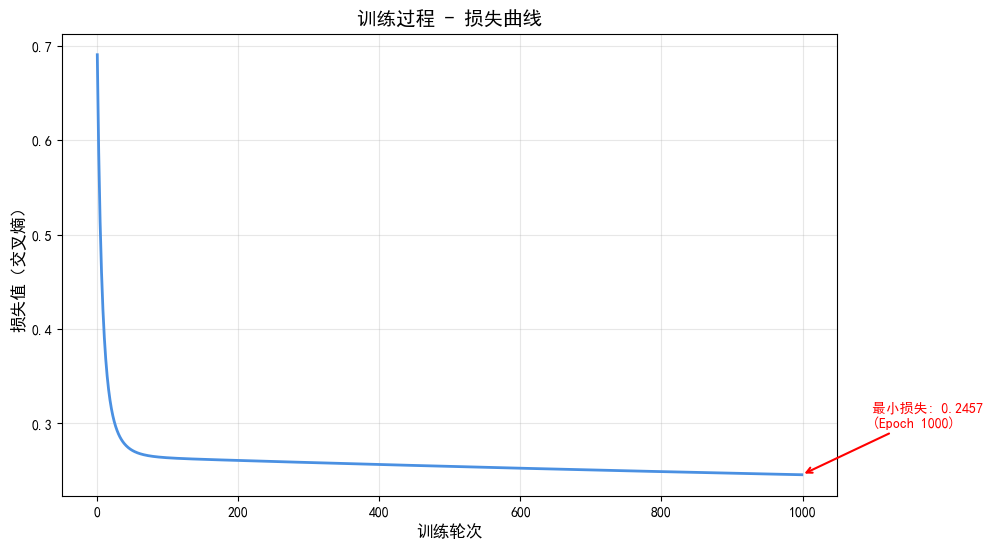

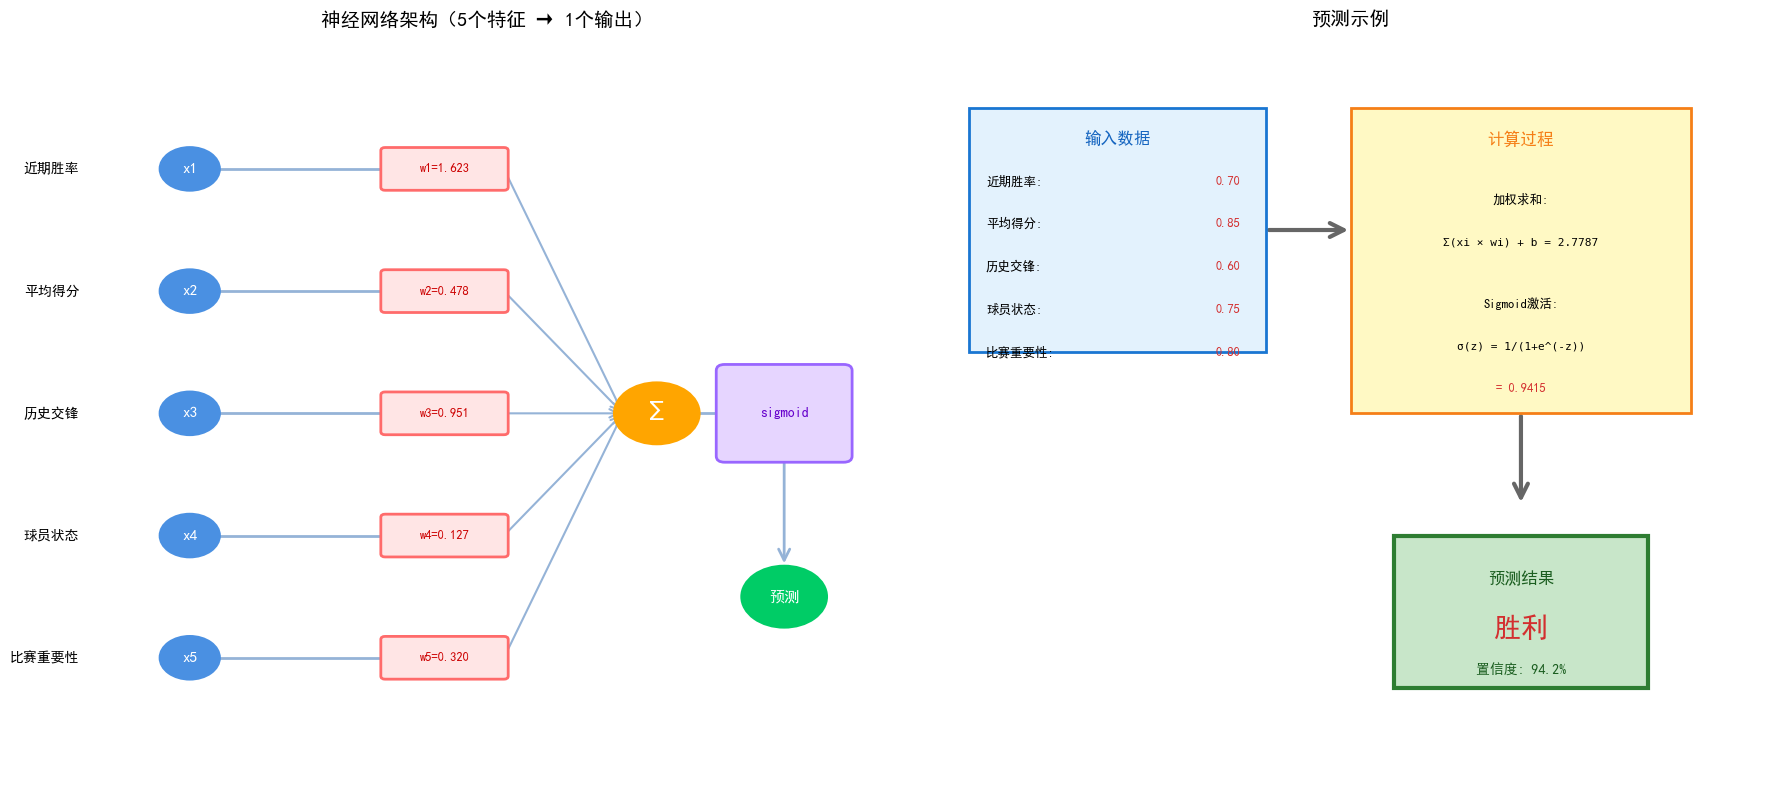


所有文件已保存到 output 文件夹


In [11]:
#体育比赛预测网络系统
#功能：基于历史数据预测比赛结果
#使用二分类神经网络， 输出胜利概率
#====================导入必要的库====================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch, Rectangle
import os
import warnings
from sklearn.metrics import accuracy_score

# plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方
warnings.filterwarnings("ignore")  # 忽略警告信息

#==============神经网络定义=============
class SportPredictor:
    """
    体育比赛预测神经网络系统
    功能：基于历史数据预测比赛结果
    """
    def __init__(self, n_features=5, learning_rate=0.01):
        """初始化预测器，设置网络的基本参数
        参数说明：
        n_features: 输入特征的数量
        learning_rate: 学习率
        """
        #保存特征数量，后续用于权重的初始化和计算
        self.n_features = n_features  # 输入特征数量
        #保存学习率，用于梯度下降时的参数更新
        self.learning_rate = learning_rate  # 学习率
        # 初始化权重和偏置
        self.weights = np.random.randn(n_features) * 0.01  # 小随机数初始化权重
        self.bias = 0.0  # 偏置初始化为0
        self.losses = []  # 用于记录训练过程中的损失值
    
    def sigmoid(self, x):
        """
        Sigmoid激活函数，将输入映射到0-1之间
        公式：sigmoid(x) = 1 / (1 + exp(-x))
        参数：x:输入值
        返回：激活后的输出值
        """
        #先使用clip函数限制x的范围，防止溢出[-500, 500]
        #然后计算sigmoid函数值，1 / (1 + exp(-x))
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def predicted(self, X):
        """
        使用训练好的模型进行预测
        参数：x:输入特征数组，形状为(n_samples, n_features)
        n_samples:样本数量, n_features:特征数量

        返回：预测的胜利概率，形状为(n_samples,)
        """
        #第一步：计算线性组合 z = x · weights + bias
        z = np.dot(X, self.weights) + self.bias
        # 第二步：应用sigmoid激活函数，得到预测概率
        return self.sigmoid(z)
    
    def train(self, X, y, epochs=1000, verbose=True):
        """
        训练神经网络模型
        参数：
        X:输入特征数组，形状为(n_samples, n_features)
        y:真实标签数组，形状为(n_samples,)
        epochs:训练轮数
        verbose:是否打印训练过程信息
        """
        n_samples = X.shape[0]  # 样本数量
        
        for epoch in range(epochs):
            # 前向传播：计算预测值
            y_pred = self.predicted(X)
            
            # 计算损失值（使用二元交叉熵损失函数）
            # 公式：-mean(y * log(y_pred) + (1 - y) * log(1 - y_pred))
            loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
            self.losses.append(loss)
            
            # 反向传播：计算梯度
            error = y_pred - y  # 预测误差
            dw = np.dot(X.T, error) / n_samples  # 权重梯度
            db = np.mean(error)  # 偏置梯度
            
            # 更新参数：梯度下降
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # 打印训练过程信息
            if verbose and (epoch + 1) % 100 == 0:
                #准确率计算
                accuracy = np.mean((y_pred >= 0.5) == y)
                print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

        #==============训练结束，打印信息=============
        if verbose:
            print("训练完成！")
            print(f"最终权重: {self.weights}")
            print(f"最终偏置: {self.bias}")
            #计算最终准确率
            final_accuracy = np.mean((y_pred >= 0.5) == y) #y_pred >=0.5为预测为1的样本 == y为真实标签
            print(f"最终准确率: {final_accuracy:.4f}")

#=============== 数据生成 ==============
def generate_sample_data(n_samples=100):
    """
    生成用于训练和测试的合成体育比赛数据
    参数：n_samples:样本数量
    返回：特征数组X和标签数组y
    特征说明：
    1. 客队近10场比赛胜率（0-1之间的浮点数）
    2. 客队平均得分（归一化0-1之间的浮点数）
    3. 主队历史胜率（0-1之间的浮点数）
    4. 客队球员状态评分（0-1之间的浮点数）
    5. 比赛重要系数（0-1之间的浮点数）
    """
    np.random.seed(42)  # 设置随机种子，确保结果可复现
    # 随机生成特征数据，假设有5个特征
    # 特征1：客队近10场比赛胜率
    recent_win_rate = np.random.uniform(0.3, 0.9, n_samples)
    # 特征2：客队平均得分（归一化0-1之间的浮点数）
    avg_score = np.random.uniform(0.5, 1.0, n_samples)
    # 特征3：主队历史胜率
    historical_win_rate = np.random.uniform(0.4, 0.95, n_samples)
    # 特征4：客队球员状态评分（0-1之间的浮点数）
    player_form = np.random.uniform(0.4, 1.0, n_samples)
    # 特征5：比赛重要系数（0-1之间的浮点数）
    match_importance = np.random.uniform(0.2, 1.0, n_samples)
    #============合并特征矩阵=========
    #column_stack函数将各个特征数组按列堆叠，形成最终的特征矩阵X
    X = np.column_stack([recent_win_rate, avg_score, historical_win_rate, player_form, match_importance])
    #============生成标签(基于特征的加权组合)=========
    #定义真实的权重，用于生成标签
    #胜率权重最大为0.4， 比赛权重最小为0.05
    true_weights = np.array([0.4, 0.2, 0.25, 0.1, 0.05])
    #计算加权和
    liner_combination = np.dot(X, true_weights)
    #添加随机噪声
    noise = np.random.normal(0, 0.05, n_samples)
    #生成二分类标签，阈值为0.5， 则标签为1，否则为0
    #astype(float)将布尔值转化为浮点数）
    y = (liner_combination + noise > 0.5).astype(float)
    return X, y

# ==================== 网络架构可视化函数 ====================
def visualize_network_architecture(model, sample_data, output_dir='output'):
    """
    可视化神经网络的架构和预测过程
    生成一张图，左边显示网络结构，右边显示实际预测示例

    参数:
        model: 已训练好的SportsPredictor模型对象
        sample_data: 一个样本的特征向量，用于演示预测过程
        output_dir: 图片保存的目录路径，默认为'output'
    """

    # 创建一个新的图形对象，大小为18英寸宽×8英寸高
    fig = plt.figure(figsize=(18, 8))

    # ==================== 左图：网络结构图 ====================
    # 创建第1个子图（1行2列布局中的第1个）
    ax1 = plt.subplot(1, 2, 1)
    # 设置x轴显示范围为0到10
    ax1.set_xlim(0, 10)
    # 设置y轴显示范围为0到12
    ax1.set_ylim(0, 12)
    # 关闭坐标轴显示，使图形更简洁美观
    ax1.axis('off')

    # 定义特征的中文名称，用于显示在图中
    feature_names = [
        '近期胜率',  # 特征1
        '平均得分',  # 特征2
        '历史交锋',  # 特征3
        '球员状态',  # 特征4
        '比赛重要性'  # 特征5
    ]

    # ========== 绘制输入层节点 ==========
    # 在y轴上等间距分布5个位置，从10到2
    input_y_positions = np.linspace(10, 2, 5)
    # 遍历每个输入节点的位置和名称
    for i, (y_pos, name) in enumerate(zip(input_y_positions, feature_names)):
        # 创建输入节点的圆形
        # 圆心在(1.5, y_pos)，半径0.35，蓝色填充
        circle = Circle((1.5, y_pos), 0.35, color='#4A90E2',
                        edgecolor='#2C5F8D',  # 深蓝色边框
                        linewidth=2,  # 边框宽度2
                        zorder=3)  # 图层顺序3（在上层）
        # 将圆形添加到子图中
        ax1.add_patch(circle)
        # 在圆心位置添加特征编号文本（x1, x2, ...）
        ax1.text(1.5, y_pos, f'x{i + 1}',  # i+1使编号从1开始
                 ha='center',  # 水平居中对齐
                 va='center',  # 垂直居中对齐
                 fontsize=11,  # 字体大小11
                 color='white',  # 白色字体
                 weight='bold',  # 粗体
                 zorder=4)  # 图层顺序4（在圆形上方）
        # 在节点左侧添加特征名称标签
        ax1.text(0.2, y_pos, name,
                 ha='right',  # 右对齐（靠近圆形）
                 va='center',  # 垂直居中
                 fontsize=10,  # 字体大小10
                 weight='bold')  # 粗体

    # ========== 绘制权重节点 ==========
    # 权重节点与输入节点的y坐标相同
    weight_y_positions = np.linspace(10, 2, 5)
    # 遍历每个权重的位置和数值
    for i, (y_pos, weight) in enumerate(zip(weight_y_positions, model.weights)):
        # 创建权重显示框（圆角矩形）
        # 左下角坐标(3.8, y_pos-0.3)，宽1.4，高0.6
        box = FancyBboxPatch((3.8, y_pos - 0.3), 1.4, 0.6,
                             boxstyle="round,pad=0.05",  # 圆角样式
                             edgecolor='#FF6B6B',  # 红色边框
                             facecolor='#FFE5E5',  # 浅红色填充
                             linewidth=2,  # 边框宽度
                             zorder=3)  # 图层顺序
        # 将权重框添加到子图中
        ax1.add_patch(box)
        # 在框中心显示权重值，格式为"w1=0.123"
        ax1.text(4.5, y_pos, f'w{i + 1}={weight:.3f}',  # 保留3位小数
                 ha='center',  # 水平居中
                 va='center',  # 垂直居中
                 fontsize=9,  # 字体大小9
                 color='#CC0000',  # 深红色字体
                 weight='bold',  # 粗体
                 zorder=4)  # 图层顺序

        # 绘制从输入节点到权重框的连接线
        # 从(1.85, y_pos)到(3.8, y_pos)的直线
        ax1.plot([1.85, 3.8], [y_pos, y_pos],
                 color='#95B3D7',  # 浅蓝色
                 linewidth=2,  # 线宽2
                 zorder=1)  # 图层顺序1（在底层）

    # ========== 绘制求和节点（Σ）==========
    # 创建求和节点的圆形，圆心在(7, 6)，半径0.5
    sum_node = Circle((7, 6), 0.5,
                      color='#FFA500',  # 橙色填充
                      edgecolor='#CC7700',  # 深橙色边框
                      linewidth=2,  # 边框宽度
                      zorder=3)  # 图层顺序
    # 将求和节点添加到子图中
    ax1.add_patch(sum_node)
    # 在圆心显示求和符号Σ
    ax1.text(7, 6, 'Σ',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=20,  # 大字体
             color='white',  # 白色
             weight='bold',  # 粗体
             zorder=4)  # 图层顺序

    # ========== 绘制权重到求和节点的箭头 ==========
    # 遍历每个权重节点的y坐标
    for y_pos in weight_y_positions:
        # 创建从权重框到求和节点的箭头
        arrow = FancyArrowPatch((5.2, y_pos),  # 起点（权重框右边）
                                (6.6, 6),  # 终点（求和节点左边）
                                arrowstyle='->',  # 箭头样式
                                mutation_scale=15,  # 箭头大小
                                color='#95B3D7',  # 浅蓝色
                                linewidth=1.5,  # 线宽
                                zorder=1)  # 图层顺序
        # 将箭头添加到子图中
        ax1.add_patch(arrow)

    # ========== 绘制Sigmoid激活函数框 ==========
    # 创建Sigmoid激活函数的显示框
    sigmoid_box = FancyBboxPatch((7.8, 5.3), 1.4, 1.4,
                                 boxstyle="round,pad=0.1",  # 圆角样式
                                 edgecolor='#9966FF',  # 紫色边框
                                 facecolor='#E6D5FF',  # 浅紫色填充
                                 linewidth=2,  # 边框宽度
                                 zorder=3)  # 图层顺序
    # 将Sigmoid框添加到子图中
    ax1.add_patch(sigmoid_box)
    # 在框中心显示"sigmoid"文本
    ax1.text(8.5, 6, 'sigmoid',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=10,  # 字体大小
             color='#6600CC',  # 深紫色
             weight='bold',  # 粗体
             zorder=4)  # 图层顺序

    # 绘制从求和节点到Sigmoid框的连接线
    ax1.plot([7.5, 7.8], [6, 6],  # 从(7.5,6)到(7.8,6)
             color='#95B3D7',  # 浅蓝色
             linewidth=2,  # 线宽2
             zorder=1)  # 图层顺序

    # ========== 绘制输出节点 ==========
    # 创建输出节点的圆形，圆心在(8.5, 3)，半径0.5
    output_circle = Circle((8.5, 3), 0.5,
                           color='#00CC66',  # 绿色填充
                           edgecolor='#009944',  # 深绿色边框
                           linewidth=2,  # 边框宽度
                           zorder=3)  # 图层顺序
    # 将输出节点添加到子图中
    ax1.add_patch(output_circle)
    # 在圆心显示"预测"文本
    ax1.text(8.5, 3, '预测',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=11,  # 字体大小
             color='white',  # 白色字体
             weight='bold',  # 粗体
             zorder=4)  # 图层顺序

    # 绘制从Sigmoid框到输出节点的箭头
    arrow = FancyArrowPatch((8.5, 5.3),  # 起点（Sigmoid框下方）
                            (8.5, 3.5),  # 终点（输出节点上方）
                            arrowstyle='->',  # 箭头样式
                            mutation_scale=20,  # 箭头大小
                            color='#95B3D7',  # 浅蓝色
                            linewidth=2,  # 线宽
                            zorder=1)  # 图层顺序
    # 将箭头添加到子图中
    ax1.add_patch(arrow)

    # 设置左图的标题
    ax1.set_title('神经网络架构（5个特征 → 1个输出）',
                  fontsize=14,  # 字体大小14
                  weight='bold',  # 粗体
                  pad=15)  # 标题与图的间距

    # ==================== 右图：实际预测示例 ====================
    # 创建第2个子图（1行2列布局中的第2个）
    ax2 = plt.subplot(1, 2, 2)
    # 设置x轴显示范围为0到10
    ax2.set_xlim(0, 10)
    # 设置y轴显示范围为0到12
    ax2.set_ylim(0, 12)
    # 关闭坐标轴显示
    ax2.axis('off')

    # ========== 绘制输入数据显示框 ==========
    # 创建矩形框用于显示输入数据
    # 左下角(0.5, 7)，宽3.5，高4
    data_box = Rectangle((0.5, 7), 3.5, 4,
                         facecolor='#E3F2FD',  # 浅蓝色填充
                         edgecolor='#1976D2',  # 蓝色边框
                         linewidth=2,  # 边框宽度
                         zorder=2)  # 图层顺序
    # 将矩形框添加到子图中
    ax2.add_patch(data_box)

    # 在框顶部显示"输入数据"标题
    ax2.text(2.25, 10.5, '输入数据',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=12,  # 字体大小12
             weight='bold',  # 粗体
             color='#1565C0')  # 深蓝色

    # ========== 显示具体的输入数据值 ==========
    # 遍历特征名称和样本数据
    for i, (name, value) in enumerate(zip(feature_names, sample_data)):
        # 计算当前特征显示的y坐标，从上到下依次递减
        y_pos = 9.8 - i * 0.7  # 每个特征间隔0.7
        # 显示特征名称（左对齐）
        ax2.text(0.7, y_pos, f'{name}:',
                 ha='left',  # 左对齐
                 va='center',  # 垂直居中
                 fontsize=9,  # 字体大小9
                 weight='bold')  # 粗体
        # 显示特征值（右对齐），保留2位小数
        ax2.text(3.7, y_pos, f'{value:.2f}',
                 ha='right',  # 右对齐
                 va='center',  # 垂直居中
                 fontsize=9,  # 字体大小
                 color='#D32F2F',  # 红色
                 weight='bold')  # 粗体

    # ========== 绘制箭头（从输入到计算）==========
    # 创建从输入框到计算框的箭头
    arrow = FancyArrowPatch((4, 9),  # 起点（输入框右侧）
                            (5, 9),  # 终点（计算框左侧）
                            arrowstyle='->',  # 箭头样式
                            mutation_scale=25,  # 箭头大小
                            color='#666',  # 灰色
                            linewidth=3,  # 线宽3
                            zorder=1)  # 图层顺序
    # 将箭头添加到子图中
    ax2.add_patch(arrow)

    # ========== 绘制计算过程显示框 ==========
    # 创建矩形框用于显示计算过程
    calc_box = Rectangle((5, 6), 4, 5,  # 左下角(5,6)，宽4，高5
                         facecolor='#FFF9C4',  # 浅黄色填充
                         edgecolor='#F57F17',  # 黄色边框
                         linewidth=2,  # 边框宽度
                         zorder=2)  # 图层顺序
    # 将计算框添加到子图中
    ax2.add_patch(calc_box)

    # 在框顶部显示"计算过程"标题
    ax2.text(7, 10.5, '计算过程',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=12,  # 字体大小
             weight='bold',  # 粗体
             color='#F57F17')  # 黄色

    # ========== 执行实际计算并显示结果 ==========
    # 第一步：计算加权和
    # z = w1*x1 + w2*x2 + w3*x3 + w4*x4 + w5*x5 + bias
    z = np.dot(sample_data, model.weights) + model.bias
    # 第二步：通过Sigmoid函数得到最终预测概率
    prediction = model.sigmoid(z)

    # 显示"加权求和"标题
    ax2.text(7, 9.5, f'加权求和:',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=9,  # 字体大小
             weight='bold')  # 粗体
    # 显示加权求和的公式和结果
    ax2.text(7, 8.8, f'Σ(xi × wi) + b = {z:.4f}',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=8,  # 字体大小
             family='monospace')  # 等宽字体

    # 显示"Sigmoid激活"标题
    ax2.text(7, 7.8, f'Sigmoid激活:',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=9,  # 字体大小
             weight='bold')  # 粗体
    # 显示Sigmoid函数公式
    ax2.text(7, 7.1, f'σ(z) = 1/(1+e^(-z))',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=8,  # 字体大小
             family='monospace')  # 等宽字体

    # 显示最终预测概率，保留4位小数
    ax2.text(7, 6.4, f'= {prediction:.4f}',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=9,  # 字体大小
             color='#D32F2F',  # 红色
             weight='bold')  # 粗体

    # ========== 绘制箭头（从计算到结果）==========
    # 创建从计算框到结果框的箭头
    arrow2 = FancyArrowPatch((7, 6),  # 起点（计算框下方）
                             (7, 4.5),  # 终点（结果框上方）
                             arrowstyle='->',  # 箭头样式
                             mutation_scale=25,  # 箭头大小
                             color='#666',  # 灰色
                             linewidth=3,  # 线宽
                             zorder=1)  # 图层顺序
    # 将箭头添加到子图中
    ax2.add_patch(arrow2)

    # ========== 绘制预测结果显示框 ==========
    # 创建矩形框用于显示最终预测结果
    result_box = Rectangle((5.5, 1.5), 3, 2.5,  # 位置和大小
                           facecolor='#C8E6C9',  # 浅绿色填充
                           edgecolor='#2E7D32',  # 绿色边框
                           linewidth=3,  # 边框宽度
                           zorder=2)  # 图层顺序
    # 将结果框添加到子图中
    ax2.add_patch(result_box)

    # 根据预测概率判断结果文本：>0.5为"胜利"，否则为"失败"
    result_text = "胜利" if prediction > 0.5 else "失败"
    # 计算置信度：如果预测胜利则置信度=预测概率，否则=1-预测概率
    confidence = prediction if prediction > 0.5 else 1 - prediction

    # 显示"预测结果"标题
    ax2.text(7, 3.3, '预测结果',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=12,  # 字体大小
             weight='bold',  # 粗体
             color='#1B5E20')  # 深绿色
    # 显示预测结果文本（"胜利"或"失败"）
    ax2.text(7, 2.5, result_text,
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=20,  # 大字体
             weight='bold',  # 粗体
             color='#D32F2F')  # 红色
    # 显示置信度百分比
    ax2.text(7, 1.8, f'置信度: {confidence:.1%}',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=10,  # 字体大小
             color='#1B5E20')  # 深绿色

    # 设置右图的标题
    ax2.set_title('预测示例',
                  fontsize=14,  # 字体大小
                  weight='bold',  # 粗体
                  pad=15)  # 标题间距

    # 自动调整子图布局，防止元素重叠
    plt.tight_layout()

    # ========== 保存图片 ==========
    # 检查输出目录是否存在
    if not os.path.exists(output_dir):
        # 如果不存在则创建目录
        os.makedirs(output_dir)
    # 构建完整的输出文件路径
    output_path = os.path.join(output_dir, 'sports_prediction_network.png')
    # 保存图片为PNG格式，分辨率300dpi，白色背景
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    # 打印保存成功的提示信息
    print(f'\n✓ 网络架构图已保存: {output_path}')


# ==================== 训练历史可视化函数 ====================
def plot_training_history(losses, output_dir='output'):
    """
    绘制训练过程中的损失曲线
    用于可视化模型的训练效果和收敛情况

    参数:
        losses: 损失值列表，每个元素是一个训练轮次的损失值
        output_dir: 图片保存目录，默认'output'
    """
    # 创建一个新的图形，大小为10×6英寸
    plt.figure(figsize=(10, 6))
    # 绘制损失曲线：x轴是轮次（自动从0开始），y轴是损失值
    plt.plot(losses,
             linewidth=2,  # 线宽2
             color='#4A90E2')  # 蓝色
    # 设置x轴标签
    plt.xlabel('训练轮次',
               fontsize=12,  # 字体大小
               weight='bold')  # 粗体
    # 设置y轴标签
    plt.ylabel('损失值（交叉熵）',
               fontsize=12,  # 字体大小
               weight='bold')  # 粗体
    # 设置图表标题
    plt.title('训练过程 - 损失曲线',
              fontsize=14,  # 字体大小
              weight='bold')  # 粗体
    # 显示网格线，透明度0.3
    plt.grid(True, alpha=0.3)

    # ========== 标注最小损失点 ==========
    # 找出损失列表中的最小值
    min_loss = min(losses)
    # 找出最小损失值对应的索引（轮次）
    min_idx = losses.index(min_loss)
    # 在图上添加箭头和文本标注
    plt.annotate(f'最小损失: {min_loss:.4f}\n(Epoch {min_idx + 1})',  # 标注文本
                 xy=(min_idx, min_loss),  # 箭头指向的点
                 xytext=(min_idx + 100, min_loss + 0.05),  # 文本框位置
                 arrowprops=dict(arrowstyle='->',  # 箭头样式
                                 color='red',  # 红色
                                 lw=1.5),  # 线宽
                 fontsize=10,  # 字体大小
                 color='red')  # 红色文字

    # 构建完整的输出文件路径
    output_path = os.path.join(output_dir, 'training_history.png')
    # 保存图片为PNG格式，分辨率300dpi
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    # 打印保存成功的提示信息
    print(f'✓ 训练历史图已保存: {output_path}')


# ==================== 主程序入口 ====================
# 当脚本被直接运行时（而不是被导入时），执行以下代码
if __name__ == '__main__':
    # ========== 第一步：生成训练数据 ==========
    # 打印提示信息
    print("正在生成训练数据...")
    # 调用函数生成100个训练样本
    # X_train: 特征矩阵(100×5)
    # y_train: 标签向量(100,)
    X_train, y_train = generate_sample_data(n_samples=100)

    # ========== 第二步：创建并训练模型 ==========
    # 创建SportsPredictor对象
    # n_features=5: 5个输入特征
    # learning_rate=0.1: 学习率0.1
    model = SportPredictor(n_features=5, learning_rate=0.1)
    # 训练模型
    # epochs=1000: 训练1000轮
    # verbose=True: 打印训练信息
    model.train(X_train, y_train, epochs=1000, verbose=True)

    # ========== 第三步：绘制训练历史 ==========
    # 将模型记录的损失历史绘制成曲线图
    plot_training_history(model.losses)

    # ========== 第四步：测试预测 ==========
    # 打印分隔线和标题
    print("\n" + "=" * 60)
    print("测试预测")
    print("=" * 60)

    # 创建一个测试样本（5个特征值）
    test_sample = np.array([0.70, 0.85, 0.60, 0.75, 0.80])  # 5个特征
    # 使用模型进行预测
    # reshape(1, -1)将一维数组转换为二维数组(1×5)
    # [0]取出第一个（也是唯一一个）预测结果
    prediction = model.predicted(test_sample.reshape(1, -1))[0]

    # 打印测试样本的特征信息
    print(f"\n测试样本特征:")
    print(f"  近期胜率: {test_sample[0]:.2f}")  # 保留2位小数
    print(f"  平均得分: {test_sample[1]:.2f}")
    print(f"  历史交锋: {test_sample[2]:.2f}")
    print(f"  球员状态: {test_sample[3]:.2f}")
    print(f"  比赛重要性: {test_sample[4]:.2f}")
    # 打印预测结果：概率>0.5判断为"胜利"，否则为"失败"
    print(f"\n预测结果: {'胜利' if prediction > 0.5 else '失败'}")
    # 打印胜利概率（百分比形式）
    print(f"胜利概率: {prediction:.2%}")
    # 打印失败概率（1减去胜利概率）
    print(f"失败概率: {(1 - prediction):.2%}")

    # ========== 第五步：可视化网络架构 ==========
    # 调用函数生成网络架构图，使用测试样本作为示例
    visualize_network_architecture(model, test_sample)

    # ========== 第六步：批量预测示例 ==========
    # 打印分隔线和标题
    print("\n" + "=" * 60)
    print("批量预测示例")
    print("=" * 60)
    # 创建3个测试样本
    test_samples = np.array([
        [0.85, 0.90, 0.75, 0.85, 0.90],  # 样本1：强队（特征值都很高）
        [0.50, 0.60, 0.45, 0.55, 0.50],  # 样本2：中等队伍
        [0.30, 0.40, 0.35, 0.45, 0.40],  # 样本3：弱队（特征值都较低）
    ])

    # 对3个样本进行批量预测
    predictions = model.predicted(test_samples)

    # 遍历每个样本的预测结果
    for i, pred in enumerate(predictions):
        # 打印样本编号、预测概率和预测结果
        print(f"\n样本 {i + 1}: 胜利概率 = {pred:.2%} ({'预测胜利' if pred > 0.5 else '预测失败'})")

    # 显示所有已创建的图形窗口
    plt.show()

    # 打印最终提示信息
    print("\n所有文件已保存到 output 文件夹")
    print("=" * 60)



        

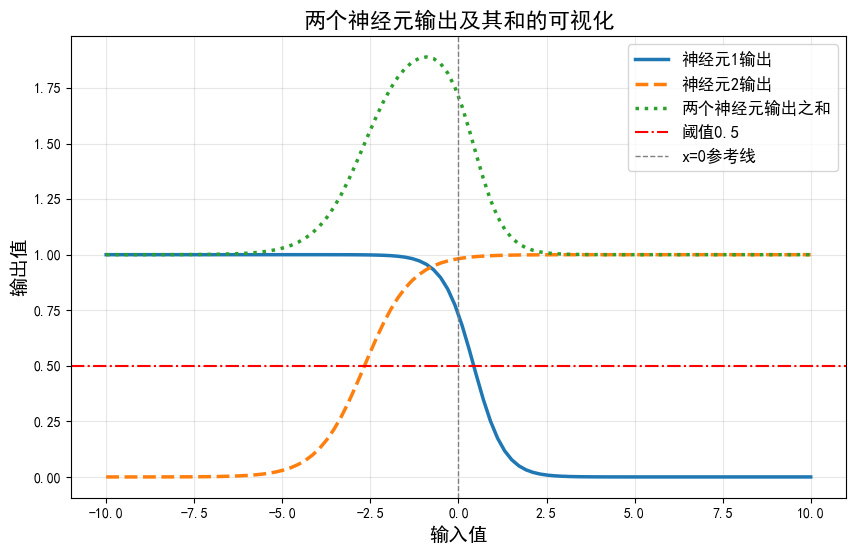

In [ ]:
from turtle import color
from pyparsing import line


plt.rcParams['font.sans-serif'] = ['SimHei', 'Times New Roman']  # 设置字体以支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
warnings.filterwarnings("ignore")  # 忽略警告信息
#=====================定义sigmoid函数======================
def sigmoid(x):
    """
    计算输入x的Sigmoid激活值
    参数：x:输入值，可以是标量或numpy数组
    返回：Sigmoid激活值
    公式：σ(x) = 1 / (1 + exp(-x))
    """
    return 1 / (1 + np.exp(-x)) #exp为绝对值函数， 为什么时-x？因为sigmoid函数的定义就是这样的
#=====================定义零个神经元参数==================
#神经元1参数
x1 = np.linspace(-10, 10, 100)  # 输入范围从-10到10，共100个点, linspace函数生成等间距的数值序列
w1 = -2.3 # 权重
b1 = 1.0  # 偏置
#神经元2参数
x2 = np.linspace(-10, 10, 100)
w2 = 1.5  # 权重
b2 = 4 # 偏置
#===============计算神经元的输出===============
y1 = sigmoid(w1 * x1 + b1)  # 神经元1输出
y2 = sigmoid(w2 * x2 + b2)  # 神经元2输出
#两个神经元输出的和
y_sum = y1 + y2
#=================控制图形==============
plt.figure(figsize=(10, 6))
plt.plot(x1, y1, label='神经元1输出', color='#1f77b4', lw=2.5, linestyle='-')  # 神经元1曲线
# 绘制神经元2输出曲线
plt.plot(x2, y2, label='神经元2输出', color='#ff7f0e', lw=2.5, linestyle='--')  # 神经元2曲线
# 绘制两个神经元输出的和曲线
plt.plot(x1, y_sum, label='两个神经元输出之和', color='#2ca02c', lw=2.5, linestyle=':')  # 输出和曲线
#添加水平参数
plt.axhline(y=0.5, color='red', linestyle='-.', lw=1.5, label='阈值0.5')  # 阈值线
#添加垂直参考线
plt.axvline(x=0, color='gray', linestyle='--', lw=1, label='x=0参考线')  # x=0参考线
# 添加图例
plt.legend(fontsize=12)
# 添加标题和轴标签
plt.title('两个神经元输出及其和的可视化', fontsize=16, weight='bold')
plt.xlabel('输入值', fontsize=14, weight='bold')
plt.ylabel('输出值', fontsize=14, weight='bold')
# 显示网格
plt.grid(True, alpha=0.3)
# 保存图形到output文件夹
# output_dir = 'output'
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)
# output_path = os.path.join(output_dir, 'two_neurons_output.png')
# plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
# print(f'✓ 两个神经元输出图已保存: {output_path}')
# 显示图形  
plt.show()


## Tanh 激活函数详解

### 什么是 Tanh 函数？
Tanh 全称为 Hyperbolic Tangent。它的数学公式为：$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
核心特性：
- 取值范围（Range）： $(-1, 1)$。这意味着无论输入多大或多小，输出永远在 -1 到 1 之间。
- 形状： S 形曲线（Sigmoid shape），但穿过原点 $(0,0)$。
- 零中心化（Zero-centered）： 这是它与 Sigmoid 函数最大的区别。Tanh 的输出均值接近 0。

### Tanh 在深度学习中有什么用？  
#### A. 解决“Zigzag”优化路径（相比 Sigmoid 的优势）  
 早期的神经网络常使用 Sigmoid 函数（输出范围 $0$ 到 $1$）。因为 Sigmoid 的输出恒为正，这会导致导致后续层的输入也恒为正。在反向传播计算梯度时，这会引起权重更新方向出现“捆绑效应”（要么全增加，要么全减少），导致梯度下降像“之”字形（Zigzag）一样震荡，收敛缓慢。  
 Tanh 的作用： 因为 Tanh 的输出有正有负（零中心化），它可以让梯度的收敛方向更加直接和高效。在大多数需要使用 S 形曲线的场景下，Tanh 通常优于 Sigmoid。  

#### B. 循环神经网络（RNN/LSTM/GRU）的核心组件  
 这是 Tanh 目前最主流的战场。
 - 防止数值爆炸： 在处理序列数据时（如时间序列预测、NLP），数据会在网络中循环传播。如果使用 ReLU（$x>0$ 时输出无限大），经过多次循环乘积后，数值容易爆炸(Exploding Gradient/Value)。
 - 信息流控制： LSTM（长短期记忆网络）和 GRU 内部的状态更新门控通常使用 Tanh。它将状态值限制在 $(-1, 1)$ 之间，既保留了非线性，又维持了数值的稳定性。    
  
 #### C. 特定的输出层需求  
 如果你的模型任务是回归问题，且目标值的范围通过数据预处理被归一化到了 $[-1, 1]$ 之间，那么在输出层直接使用 Tanh 是非常合适的。
 - 例子： 在生成对抗网络（GAN）中，生成器（Generator）的最后一层常用 Tanh，将生成的像素值映射回 $[-1, 1]$ 以匹配预处理后的图像数据。

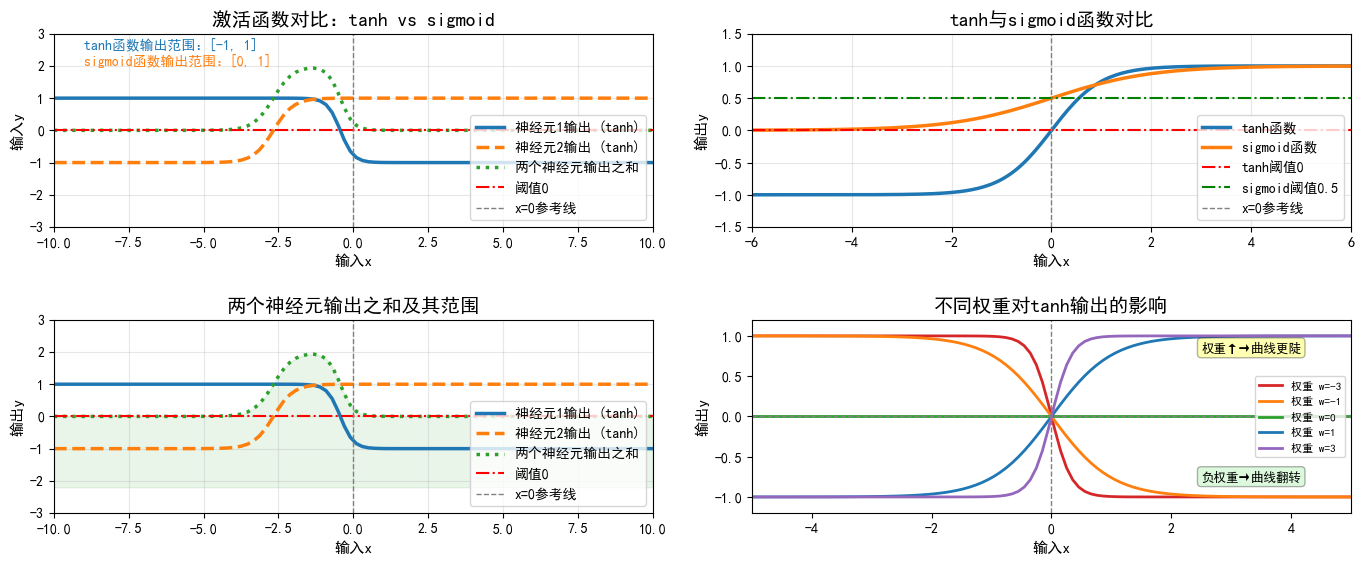

In [6]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Times New Roman']  # 设置字体以支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
#忽略字体警告
warnings.filterwarnings("ignore")  # 忽略警告信息

#==================定义tanh激活函数===============
def tanh(x):
    """
    计算输入x的tanh激活值
    参数：x:输入值，可以是标量或numpy数组
    返回：tanh激活值
    公式：tanh(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))
    """
    return np.tanh(x) #使用numpy的tanh函数计算双曲正切值
#==================定义两个神经元参数===============
#神经元1的参数
x1 = np.linspace(-10, 10, 100)  # 输入范围从-10到10，共100个点
w1 = -2.3  # 权重
b1 = -1.0  # 偏置
#神经元2的参数
x2 = np.linspace(-10, 10, 100)
w2 = 1.5  # 权重
b2 = 4.0  # 偏置
#================计算神经元的输出===============
#神经源1的输出y1 = tanh(w1 * x1 + b1)
y1 = tanh(w1 * x1 + b1)  # 神经元1输出
#神经元2的输出y2 = tanh(w2 * x2 + b2)
y2 = tanh(w2 * x2 + b2)  # 神经元2输出
#计算神经元输出和线性组合
#展示神经网络的非线性特性
y_sum = y1 + y2
#================绘制对比图================
def sigmod(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # 防止溢出
#创建对比数据
x_compare = np.linspace(-6, 6, 200)
y_tanh = np.tanh(x_compare)
y_sigmoid = sigmod(x_compare)

#==============创建综合图形==============
fig = plt.figure(figsize=(14, 6))
#==============子图1：神经元输出对比图=============
ax1 = plt.subplot(2, 2, 1)
ax1.plot(x1, y1, label='神经元1输出 (tanh)', color='#1f77b4', lw=2.5, linestyle='-')  # 神经元1曲线
ax1.plot(x2, y2, label='神经元2输出 (tanh)', color='#ff7f0e', lw=2.5, linestyle='--')  # 神经元2曲线
ax1.plot(x1, y_sum, label='两个神经元输出之和', color='#2ca02c', lw=2.5, linestyle=':')  # 输出和曲线
ax1.axhline(y=0, color='red', linestyle='-.', lw=1.5, label='阈值0')  # 阈值线
ax1.axvline(x=0, color='gray', linestyle='--', lw=1, label='x=0参考线')  # x=0参考线
ax1.legend(fontsize=10, loc='lower right')
ax1.set_xlabel('输入x', fontsize=11, weight='bold')
ax1.set_ylabel('输入y', fontsize=11, weight='bold')
ax1.set_title('激活函数对比：tanh vs sigmoid', fontsize=14, weight='bold')
ax1.set_xlim(-10, 10)
ax1.set_ylim(-3, 3)
#添加文本
ax1.text(-9, 2.5, 'tanh函数输出范围：[-1, 1]', fontsize=10, color='#1f77b4')
ax1.text(-9, 2.0, 'sigmoid函数输出范围：[0, 1]', fontsize=10, color='#ff7f0e')
ax1.grid(True, alpha=0.3)
#==============子图2：tanh与sigmoid对比图=============
ax2 = plt.subplot(2, 2, 2)
ax2.plot(x_compare, y_tanh, label='tanh函数', color='#1f77b4', lw=2.5)
ax2.plot(x_compare, y_sigmoid, label='sigmoid函数', color='#ff7f0e', lw=2.5)
ax2.axhline(y=0, color='red', linestyle='-.', lw=1.5, label='tanh阈值0')  # tanh阈值线
ax2.axhline(y=0.5, color='green', linestyle='-.', lw=1.5, label='sigmoid阈值0.5')  # sigmoid阈值线
ax2.axvline(x=0, color='gray', linestyle='--', lw=1, label='x=0参考线')  # x=0参考线
ax2.legend(fontsize=10)
ax2.set_xlabel('输入x', fontsize=11, weight='bold')
ax2.set_ylabel('输出y', fontsize=11, weight='bold')
ax2.set_title('tanh与sigmoid函数对比', fontsize=14, weight='bold')
ax2.set_xlim(-6, 6)
ax2.set_ylim(-1.5, 1.5)
ax2.grid(True, alpha=0.3)
#===============子图3：神经元输出和图=============
ax3 = plt.subplot(2, 2, 3)
ax3.plot(x1, y1, label='神经元1输出 (tanh)', color='#1f77b4', lw=2.5, linestyle='-')  # 神经元1曲线
ax3.plot(x2, y2, label='神经元2输出 (tanh)', color='#ff7f0e', lw=2.5, linestyle='--')  # 神经元2曲线
ax3.plot(x1, y_sum, label='两个神经元输出之和', color='#2ca02c', lw=2.5, linestyle=':')  # 输出和曲线
#添加水平参考线
ax3.axhline(y=0, color='red', linestyle='-.', lw=1.5, label='阈值0')  # 阈值线
ax3.axvline(x=0, color='gray', linestyle='--', lw=1, label='x=0参考线')  # x=0参考线
#填充区域显示输出和的范围
ax3.fill_between(x1, -2.2, y_sum, alpha=0.1, color='#2ca02c')
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('输入x', fontsize=11, weight='bold')
ax3.set_ylabel('输出y', fontsize=11, weight='bold')
ax3.set_title('两个神经元输出之和及其范围', fontsize=14, weight='bold')
ax3.legend(fontsize=10, loc='lower right')
ax3.set_xlim(-10, 10)
ax3.set_ylim(-3, 3)
#================子图4：参数效果分析=============
ax4 = plt.subplot(2, 2, 4)
#显示不同的权重效果
x_demo = np.linspace(-5, 5, 100)
y_demo = np.linspace(-5, 5, 100)
weights = [-3, -1, 0, 1, 3]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
for w, color in zip(weights, colors):
    y_param = tanh(w * x_demo)
    ax4.plot(x_demo, y_param, label=f'权重 w={w}', color=color, lw=2)
ax4.axhline(y=0, color='gray', linestyle='--', lw=1)  # y=0参考线
ax4.axvline(x=0, color='gray', linestyle='--', lw=1)  # x=0参考线
ax4.set_xlabel('输入x', fontsize=11, weight='bold')
ax4.set_ylabel('输出y', fontsize=11, weight='bold')
ax4.set_title('不同权重对tanh输出的影响', fontsize=14, weight='bold')
ax4.legend(fontsize=8)

ax4.set_xlim(-5, 5)
ax4.set_ylim(-1.2, 1.2)
# 添加说明文本
ax4.text(x=2.5, y=0.8, s='权重↑→曲线更陡', fontsize=9,
bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
ax4.text(x=2.5, y=-0.8, s='负权重→曲线翻转', fontsize=9,
bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

# 调整整体布局
plt.tight_layout (pad=2.0)
# end for
# #显示图形
plt.show()



## Tanh vs Sigmoid vs ReLU
| **特性**     | **Sigmoid**  | **Tanh**                 | **ReLU**            |
| :------------: | :------------: | :------------------------: | :-------------------: |
| **数学公式** | $\sigma(x) = \frac{1}{1 + e^{-x}}$ | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $f(x) = \max(0, x)$ |
| **numpy 实现** | `1 / (1 + np.exp(-x))` | `np.tanh(x)`           | `np.maximum(0, x)`   |
| **输出范围:值域** | $(0, 1)$     | **$(-1, 1)$**            | $[0, +\infty)$      |
| **零中心化** | 否           | **是**（主要优势）       | 否                  |
| **梯度消失** | 严重         | **严重**（在两端饱和时） | 无（在正区间）      |
| **主要应用** | 二分类输出层 | **RNN/LSTM，GAN 生成器** | CNN，大多数深层网络 |
| **图像形状**|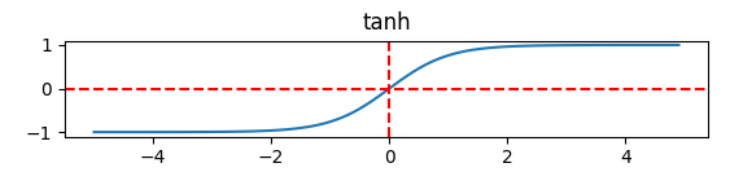|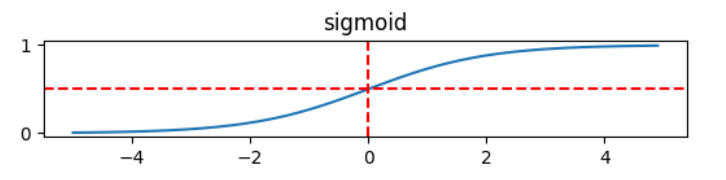|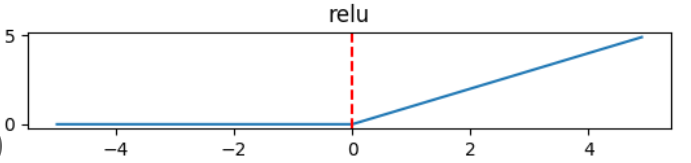|


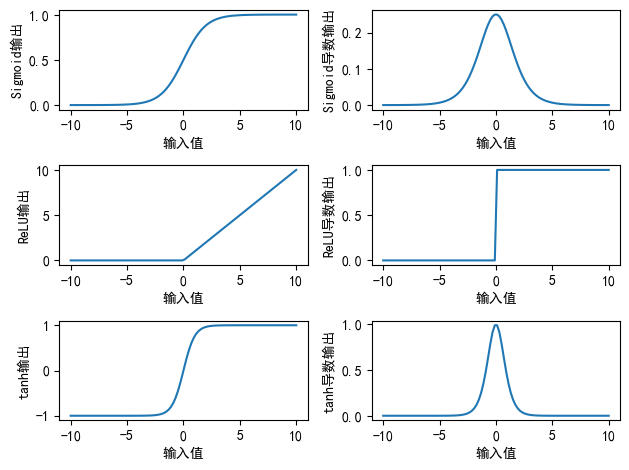

In [ ]:
import matplotlib.pyplot as plt
from torch import sigmoid_
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Times New Roman']  # 设置字体以支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

#创建一个新的图形，大小为12×6英寸
inputs = np.array(np.linspace(-10, 10, 100))  #输入范围从-10到10，共100个点
#定义sigmoid函数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#计算输入值对应的sigmoid输出
sigmoid_outputs = sigmoid(inputs)
#创建子图，并绘制sigmoid函数曲线
plt.subplot(3, 2, 1)
plt.plot(inputs, sigmoid_outputs)
plt.xlabel('输入值')
plt.ylabel('Sigmoid输出')

#定义sigmoid函数的导数
def sigmoid_derivative(x):
    sig = 1.0/(1.0 + np.exp(-x)) #计算sigmoid值
    return sig * (1 - sig) #计算导数值：为什么是sig * (1 - sig)？因为这是sigmoid函数导数的定义
#创建子图，并绘制sigmoid函数导数曲线
plt.subplot(3, 2, 2)
sigmod_de_outputs = sigmoid_derivative(inputs) #计算导数输出
plt.plot(inputs, sigmod_de_outputs)
plt.xlabel('输入值')
plt.ylabel('Sigmoid导数输出')

#定义Relu激活函数
def relu(x):
    return np.maximum(0, x)
#创建子图，并绘制Relu函数曲线
plt.subplot(3, 2, 3)
plt.plot(inputs, relu(inputs))
plt.xlabel('输入值')
plt.ylabel('ReLU输出')
#定义Relu函数的导数
def relu_derivative(x):
    return np.where(x > 0, 1, 0) #大于0时导数为1，否则为0
#计算输入值对应的Relu导数输出
relu_de_outputs = relu_derivative(inputs)
#绘制3x3子图中的第4个子图
plt.subplot(3, 2, 4)
plt.plot(inputs, relu_de_outputs)
plt.xlabel('输入值')
plt.ylabel('ReLU导数输出')
#定义tanh激活函数
def tanh(x):
    return np.tanh(x)
#创建子图，并绘制tanh函数曲线
plt.subplot(3, 2, 5)
plt.plot(inputs, tanh(inputs))
plt.xlabel('输入值')
plt.ylabel('tanh输出')
#定义tanh函数的导数
def tanh_derivative(x):
    return 1.0 - np.tanh(x)**2
#计算输入值对应的tanh导数输出
tanh_de_outputs = tanh_derivative(inputs)
#绘制3x3子图中的第6个子图
plt.subplot(3, 2, 6)
plt.plot(inputs, tanh_de_outputs)
plt.xlabel('输入值')
plt.ylabel('tanh导数输出')
#自动调整子图布局，防止元素重叠
plt.tight_layout()
#显示图形
plt.show()

In [9]:
#ModelTrainer.py, 全连接
from networkx import current_flow_betweenness_centrality
import torch
#导入pytorch的神经网络模块，包含各种层和激活函数
import torch.nn as nn
import numpy as np
import random
import os
#导入joblib库，用于模型的保存和加载
import joblib
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

def setup_seed(seed):
    """
    设置随机种子，确保结果可复现
    参数:
        seed: 整数类型的随机种子
    """
    torch.manual_seed(seed) # 设置CPU随机种子
    #设置GPU随机种子（如果使用GPU）
    torch.cuda.manual_seed_all(seed)
    #设置numpy随机种子
    np.random.seed(seed)
    #设置CUDNN的确定性模式
    torch.backends.cudnn.deterministic = True

# 调用函数，设置随机种子为42
setup_seed(42) 
class FCNModel(nn.Module): # 全连接神经网络模型
    """
    定义一个简单的全连接神经网络模型
    用于二分类任务

    """
    def __init__(self, input_size, hidden_sizes=[512, 256, 128, 64], output_size=1, dropout=0.2):
        """     
        参数：
        input_size: 输入特征的维度
        hidden_sizes: 隐藏层的神经元数量列表默认为[512, 256, 128, 64]
        output_size: 输出层的神经元数量，默认为1（用于二分类）
        dropout: Dropout层的丢弃概率，默认为0.2
        """
        super(FCNModel, self).__init__()
        # 创建空列表用于存储网络层
        layers = []
        #当前输入维度，初始为输入的特征维度
        current_size = input_size
        #遍历隐藏层的神经元数量列表
        for h_size in hidden_sizes:
            #添加线性层
            layers.append(nn.Linear(current_size, h_size))
            #添加添加SiLU激活函数层，也称为Swish激活函数
            layers.append(nn.SiLU())
            #添加批归一化层，加速训练收敛
            layers.append(nn.BatchNorm1d(h_size))
            #添加Dropout层
            layers.append(nn.Dropout(dropout))
            #更新当前输入维度为当前隐藏层的输出维度，以便下一层使用
            current_size = h_size

        #将所有的层组合成一个顺序容器
        self.feature_layers = nn.Sequential(*layers)
        #最终输出层，将最后的隐藏层映射到输出维度
        self.final = nn.Linear(current_size, output_size)
        #应用权重初始化方法到所层
        self.apply(self._init_weights)


    def _init_weights(self, m):
        """
        权重初始化方法
        参数:
            m: 神经网络层
        """
        if isinstance(m, nn.Linear):
            #使用Xavier均匀分布初始化线性层的权重
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                #将偏置初始化为0
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        定义前向传播过程
        参数:
            x: 输入数据张量
        返回:
            输出概率张量
        """
        return self.final(self.feature_layers(x))

class ModelTrainer:
    """
    模型训练器类
    用于训练、评估和保存全连接神经网络模型
    """
    def __init__(self, input_size, hidden_sizes=[512, 256, 128, 64], output_size=1, dropout=0.2, learning_rate=0.001,decice=None):
        """
        参数:
            input_size: 输入特征的维度
            hidden_sizes: 隐藏层的神经元数量列表，默认为[512, 256, 128, 64]
            output_size: 输出层的神经元数量，默认为1（用于二分类）
            dropout: Dropout层的丢弃概率，默认为0.2
            learning_rate: 学习率，默认为0.001
            device: 计算设备，默认为None（自动选择CPU或GPU）,为None时自动选择
        """
        self.device = torch.device('cuda' if torch.cuda.is_available() and decice=='cuda' else 'cpu')
        print(f'使用设备: {self.device}')
        #保存隐层参数
        self.hidden_sizes = hidden_sizes
        # 初始化全连接神经网络模型
        self.model = None
        #定义二分类交叉熵损失函数
        self.criterion = nn.BCEWithLogitsLoss()
        #定义Adam优化器
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        #初始化标准化器
        self.scaler = StandardScaler()
        #保存损失历史
        self.history = {'train_loss': [], 'val_loss': []}
        #初始化最佳验证损失为无穷大
        self.best_val_loss = float('inf')
    def train_from_numpy(self, X_train, y_train, val_split=0.1, batch_size=2048, epochs=100, lr=1e-3):
        """
        使用numpy数组训练模型
        参数:
            val_split: 验证集比例，默认为0.1
            batch_size: 批次大小，默认为2048
            epochs: 训练轮次，默认为100
            lr: 学习率，默认为1e-3

            X_train: 训练特征数据，numpy数组
            y_train: 训练标签数据，numpy数组
            X_val: 验证特征数据，numpy数组，默认为None
            y_val: 验证标签数据，numpy数组，默认为None
            epochs: 训练轮次，默认为100
            batch_size: 批次大小，默认为32
            verbose: 是否打印训练信息，默认为True
            save_path: 模型保存路径，默认为'model.pkl'
        """
        #归一化特征
        #使用StandardScaler进行标准化
        X_scaled = self.scaler.fit_transform(X_train)
        #将归一化后的数据转换为PyTorch张量
        X_tensor = torch.FloatTensor(X_scaled)
        #将目标标签转换为PyTorch张量，并调整形状为(-1, 1)
        y_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        #获取数据集总大小
        dataset_size = len(X_tensor)
        #计算验证机大小
        val_size = int(dataset_size * val_split)
        #计算训练集大小
        train_size = dataset_size - val_size
        #使用random_split随机划分训练集和验证机
        train_dataset, val_dataset = torch.utils.data.random_split(
            TensorDataset(X_tensor, y_tensor),
            [train_size, val_size]
        )
        #创建训练数据加载器，suffle=True打乱数据
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        #创建验证数据加载器，shuffle=False不打乱数据
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        #如果模型未创建
        if self.model is None:
            #创建FCNModel模型实例
            self.model = FCNModel(
                input_size=X_train.shape[1],
                hidden_sizes=self.hidden_sizes,
                output_size=1,
                dropout=0.2
            ).to(self.device)
        #调用训练器并返回训练结果
        return self._train_loop(train_loader, val_loader, epochs, lr)
    def _train_loop(self, train_loader, val_loader, epochs, lr):
        """
        训练循环
        参数:
            train_loader: 训练数据加载器
            val_loader: 验证数据加载器
            epochs: 训练轮次
            lr: 学习率
        返回:
            训练历史字典，包含训练损失和验证损失列表
        """
        #定义损失函数为均方误差，适合回归任务
        criterion = nn.MSELoss()
        #定义优化器为Adam优化器
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)
        #学习率调度器，减少学习率
        #ReduceLROnPlateau在验证损失不再改善时减少学习率
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        #早停机制参数
        patience = 30  # 提前停止的耐心值
        # 早停计数器
        early_stop_counter = 0
        #开始训练循环
        for epoch in range(epochs):
            # 训练模式
            self.model.train()
            train_losses = []
            # 遍历训练数据加载器
            for X_batch, y_batch in train_loader:
                # 将数据移动到指定设备
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                # 前向传播
                outputs = self.model(X_batch)
                # 计算损失
                loss = criterion(outputs, y_batch)
                # 清零梯度
                optimizer.zero_grad()
                # 反向传播
                loss.backward()
                # 更新参数
                optimizer.step()
                # 记录训练损失
                train_losses.append(loss.item())
            # 计算平均训练损失
            avg_train_loss = np.mean(train_losses)
            # 验证模式
            self.model.eval()
            val_losses = []
            # 禁用梯度计算
            with torch.no_grad():
                # 遍历验证数据加载器
                for X_batch, y_batch in val_loader:
                    # 将数据移动到指定设备
                    X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                    # 前向传播
                    outputs = self.model(X_batch)
                    # 计算损失
                    loss = criterion(outputs, y_batch)
                    # 记录验证损失
                    val_losses.append(loss.item())
            # 计算平均验证损失
            avg_val_loss = np.mean(val_losses)
            # 调整学习率
            scheduler.step(avg_val_loss)
            # 打印训练信息
            print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
            # 保存训练历史
            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)
            # 检查是否需要早停
            if avg_val_loss < self.best_val_loss:
                self.best_val_loss = avg_val_loss
                early_stop_counter = 0  # 重置计数器
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print("验证损失未改善，提前停止训练。")
                    break  # 提前停止训练